# M5 Forecasting - Accuracy: Walmart Sales Prediction

## Introduction

Welcome to this notebook for the **M5 Forecasting - Accuracy** Kaggle competition. The primary objective of this project is to accurately predict the daily sales for the next 28 days of over 3,000 hierarchical products across 10 Walmart stores in three distinct US states (California, Texas, and Wisconsin).

Working with this dataset presents unique challenges, particularly dealing with a massive volume of data (tens of millions of rows), hierarchical product structures, intermittent demand (frequent zero-sales days), and the strong influence of external localized factors such as special events and SNAP (Supplemental Nutrition Assistance Program) distribution days. This notebook is designed to tackle these challenges through a highly optimized, memory-efficient, and structured data science pipeline.

## Workflow Overview

The code in this notebook follows a systematic, step-by-step pipeline—from handling raw data to crafting predictive features:

**Step 1: Data Loading & Memory Optimization**
* Loads the three core datasets: historical sales (`sales_train_evaluation`), calendar events (`calendar`), and item pricing (`sell_prices`).
* Applies a custom `reduce_mem_usage()` function to drastically reduce the dataframe's memory footprint. It dynamically downcasts numerical types (e.g., from `float64` to `float16`) and converts object strings to `category` types, which is a critical step to prevent Out-Of-Memory (OOM) crashes.


**Step 2: Data Reshaping & Merging**
* Transforms the sales dataset from a "wide" format (days as columns) into a "long" format (days as rows) using the `pd.melt()` function, making it compatible with machine learning models.
* Combines the melted sales data with the calendar and pricing datasets using `pd.merge()`, creating a single, comprehensive master dataframe containing all relevant variables.


**Step 3: Exploratory Data Analysis (EDA) & Visualization**
* Visualizes the macro-level, long-term historical sales trends to identify overall growth and holiday-related anomalies (e.g., zero sales on Christmas).
* Breaks down sales volumes by state and product category to identify core business drivers.
* Investigates micro-level patterns, including weekly seasonality and intermittent demand severity.
* Analyzes the specific impact of external drivers, specifically how different event types and SNAP benefit days temporarily inflate consumer demand.


**Step 4: Feature Engineering (Time Series Features)**
* Chronologically sorts the dataset to ensure temporal consistency before creating time-based variables.
* **Lag Features:** Generates historical sales data variables (e.g., `lag_28`). A minimum shift of 28 days is utilized to completely avoid data leakage during the required 28-day prediction horizon.
**Rolling Window Statistics:** Calculates moving averages (e.g., 7-day and 28-day rolling means) based on the lagged features to capture recent sales momentum, trend stabilization, and volatility.

# 1. Prepare Data

## 1.1. Import Library Package

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc
import joblib

# ML Model
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')

## 1.2. Import Data

In [84]:
sales = pd.read_csv('sales_train_evaluation.csv')
sales.name = 'sales'

sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [85]:
#Add zero sales for the remaining days 1942-1969 (28 days prediction)
for d in range(1942,1970):
    col = 'd_' + str(d)
    sales[col] = 0
    sales[col] = sales[col].astype(np.int16)

In [86]:
calendar = pd.read_csv('calendar.csv')
calendar.name = 'calendar'

calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [87]:
prices = pd.read_csv('sell_prices.csv')
prices.name = 'prices'

prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


## 1.3. See information of Data

In [88]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1975 entries, id to d_1969
dtypes: int16(28), int64(1941), object(6)
memory usage: 454.5+ MB


In [89]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1960,d_1961,d_1962,d_1963,d_1964,d_1965,d_1966,d_1967,d_1968,d_1969
count,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,30490.000000,...,30490.0,30490.0,30490.0,30490.0,30490.0,30490.0,30490.0,30490.0,30490.0,30490.0
mean,1.070220,1.041292,0.780026,0.833454,0.627944,0.958052,0.918662,1.244080,1.073663,0.838701,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,5.126689,5.365468,3.667454,4.415141,3.379344,4.785947,5.059495,6.617729,5.917204,4.206199,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,360.000000,436.000000,207.000000,323.000000,296.000000,314.000000,316.000000,370.000000,385.000000,353.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [90]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [91]:
calendar.describe()

,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI
count,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000
mean,11347.086338,3.997461,6.325546,2013.288471,0.330117,0.330117,0.330117
std,155.277043,2.001141,3.416864,1.580198,0.470374,0.470374,0.470374
min,11101.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000
25%,11219.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000
50%,11337.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000
75%,11502.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000
max,11621.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000


In [92]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [93]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


# 2. Memory Reduction

In [94]:
def reduce_mem_usage(df, df_name = True, verbose=True):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'Dataframe: {str(df_name)}')
        print(f'Memory usage of dataframe: {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype
        #----------------------------------------------------------------------------------------------------
        if pd.api.types.is_integer_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
        #----------------------------------------------------------------------------------------------------
        elif pd.api.types.is_float_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                df[col] = df[col].astype(np.float16)
            elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
        #----------------------------------------------------------------------------------------------------
        elif pd.api.types.is_object_dtype(col_type):
            if col == 'date':
                df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')
            else:
                df[col] = df[col].astype('category')
        #----------------------------------------------------------------------------------------------------

    end_mem = df.memory_usage(deep=True).sum() / 1024**2

    if verbose:
        print(f'Memory usage after optimization: {end_mem:.2f} MB')
        print(f'Decreased by {(100 * (start_mem - end_mem) / start_mem):.2f}%')
        print('=' * 80)
    return df

# Apply the optimized function to your dataframes
sales = reduce_mem_usage(sales, 'sales')
calendar = reduce_mem_usage(calendar, 'calendar')
prices = reduce_mem_usage(prices, 'prices')

Dataframe: sales
Memory usage of dataframe: 463.52 MB
Memory usage after optimization: 99.29 MB
Decreased by 78.58%
Dataframe: calendar
Memory usage of dataframe: 0.67 MB
Memory usage after optimization: 0.21 MB
Decreased by 68.06%
Dataframe: prices
Memory usage of dataframe: 853.13 MB
Memory usage after optimization: 45.91 MB
Decreased by 94.62%


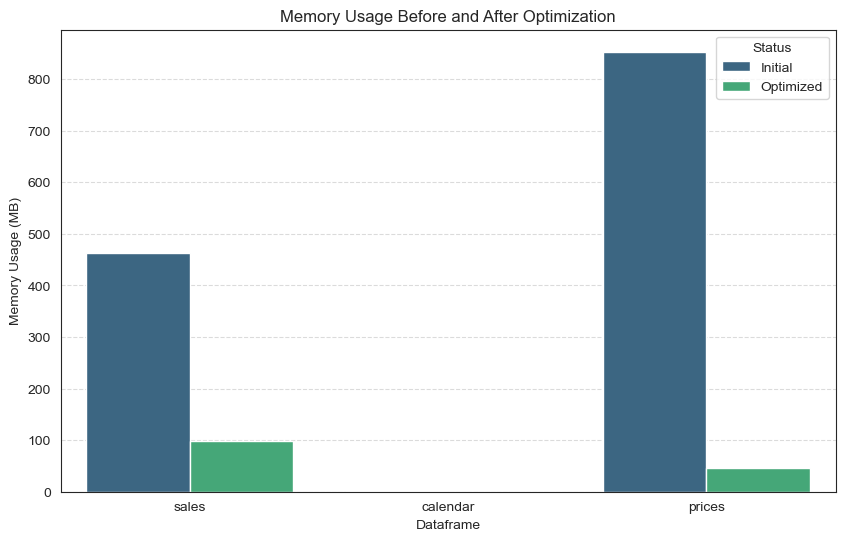

In [95]:
# Data extracted from the provided output
initial_mem = {
    'sales': 461.90,
    'calendar': 0.67,
    'prices': 853.13
}
optimized_mem = {
    'sales': 98.48,
    'calendar': 0.21,
    'prices': 45.91
}

# Create a DataFrame for plotting
data = {
    'Dataframe': list(initial_mem.keys()) * 2,
    'Memory (MB)': list(initial_mem.values()) + list(optimized_mem.values()),
    'Status': ['Initial'] * len(initial_mem) + ['Optimized'] * len(optimized_mem)
}
df_mem = pd.DataFrame(data)

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Dataframe', y='Memory (MB)', hue='Status', data=df_mem, palette='viridis')
plt.title('Memory Usage Before and After Optimization')
plt.ylabel('Memory Usage (MB)')
plt.xlabel('Dataframe')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Reconstructure and Combine Data

## 3.1 Convert from wide to long format

In [96]:
df = pd.melt(sales, id_vars=['id', 'item_id', 'dept_id',
                             'cat_id', 'store_id', 'state_id'],
             var_name='d', value_name='sold').dropna()

In [97]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sold
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


## 3.2 Combine the data

Combine price data from `prices` dataframe and days data from `calendar` dataset.

In [98]:
df = pd.merge(df, calendar, on='d', how='left')
df = pd.merge(df, prices, on=['store_id','item_id','wm_yr_wk'], how='left')

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60034810 entries, 0 to 60034809
Data columns (total 22 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            category      
 1   item_id       category      
 2   dept_id       category      
 3   cat_id        category      
 4   store_id      category      
 5   state_id      category      
 6   d             object        
 7   sold          int16         
 8   date          datetime64[ns]
 9   wm_yr_wk      int16         
 10  weekday       category      
 11  wday          int8          
 12  month         int8          
 13  year          int16         
 14  event_name_1  category      
 15  event_type_1  category      
 16  event_name_2  category      
 17  event_type_2  category      
 18  snap_CA       int8          
 19  snap_TX       int8          
 20  snap_WI       int8          
 21  sell_price    float16       
dtypes: category(11), datetime64[ns](1), float16(1), int16(3), int8(5

# 4. Exploratory Data Analysis

## 4.1 Set global template

In [118]:
import os

# 1. Create 'Picture' directory if it doesn't exist
os.makedirs('Picture', exist_ok=True)

# 2. Set global aesthetics: clean white background, no grid
sns.set_style("white")

# 3. Define a unified custom color palette for all charts
# Using a refined, modern palette (Blue, Orange, Green, Red, Purple tones)
unified_palette = sns.color_palette("muted")
sns.set_palette(unified_palette)
main_color = unified_palette[0] # Primary blue for single-color plots

# 4. Define a helper function to format plots and save them
def format_and_save(ax, title, xlabel, ylabel, filename):
    ax.set_title(title, fontsize=16, pad=15, fontweight='bold', color='#333333')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10, color='#555555')
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10, color='#555555')
    
    # Remove top and right borders for a cleaner look
    sns.despine()
    plt.tight_layout()
    
    # Save the figure to the Picture folder with high resolution
    plt.savefig(f'Picture/{filename}.png', dpi=300, bbox_inches='tight')
    print(f"Saved: Picture/{filename}.png")

## 4.2 Long-term Sales Trend

Saved: Picture/01_LongTerm_Sales_Trend.png


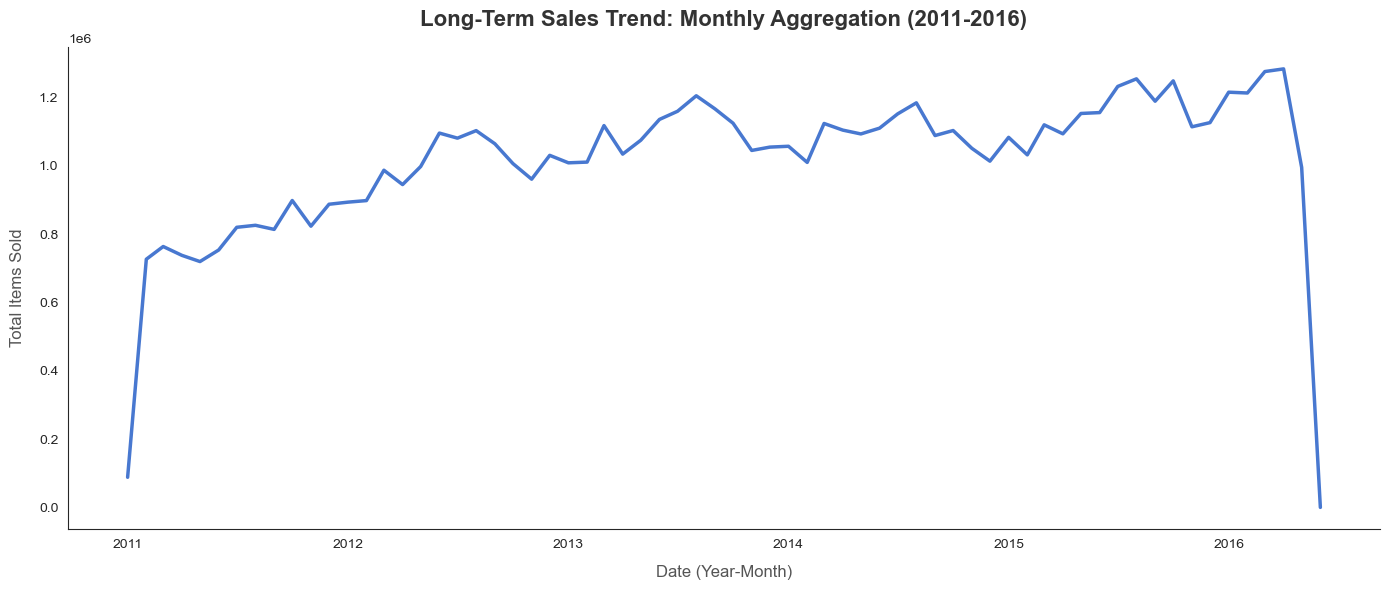

In [119]:
# Aggregate total sales by year and month
monthly_sales = df.groupby(pd.Grouper(key='date', freq='MS'))['sold'].sum().reset_index()

# Plotting
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='date', y='sold', color=main_color, linewidth=2.5, ax=ax)

# Format and save
format_and_save(ax, 
                title='Long-Term Sales Trend: Monthly Aggregation (2011-2016)', 
                xlabel='Date (Year-Month)', 
                ylabel='Total Items Sold', 
                filename='01_LongTerm_Sales_Trend')

plt.show()

Overall Growth: The total sales volume demonstrates a consistent upward trajectory from 2011 to early 2016, indicating steady business growth.

Holiday Drops: The recurring, sharp downward spikes represent Christmas days when Walmart stores are closed, resulting in zero sales.

Edge Artifacts: The steep drops at the very beginning (2011) and the end (2016) are due to incomplete monthly data in the dataset.

## 4.3 Sales Volume seperate by State and Category

Saved: Picture/02_Sales_by_State_Category_Horizontal.png


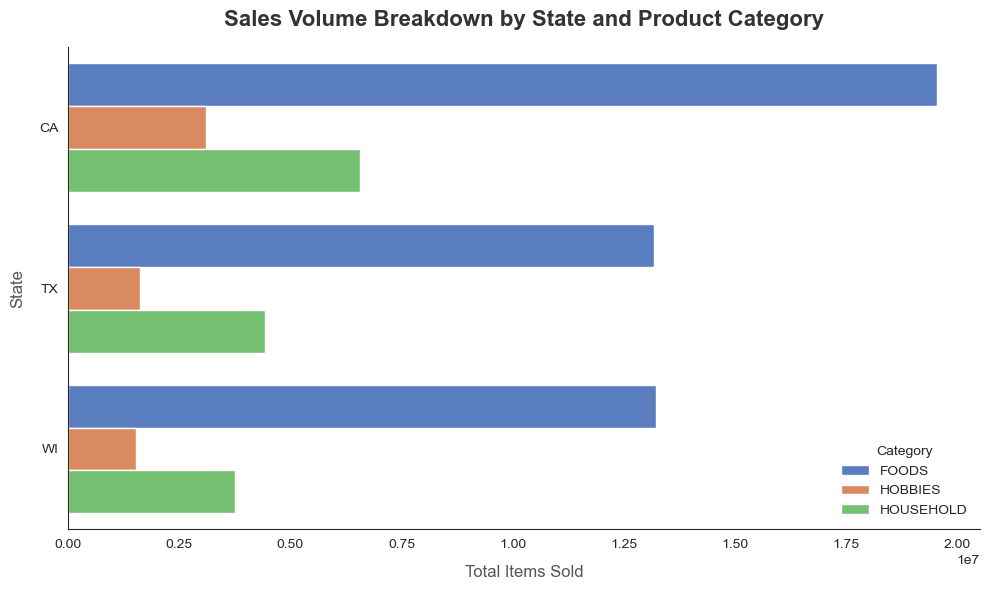

In [120]:
# Aggregate sales by state and category
# Aggregate sales by state and category
cat_state_sales = df.groupby(['state_id', 'cat_id'])['sold'].sum().reset_index()
cat_state_sales['state_id'] = cat_state_sales['state_id'].astype(str)
cat_state_sales['cat_id'] = cat_state_sales['cat_id'].astype(str)

# Plotting (Horizontal Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=cat_state_sales, 
            x='sold', 
            y='state_id', 
            hue='cat_id', 
            orient='h', 
            ax=ax)

# Clean up the legend
plt.legend(title='Category', frameon=False, loc='lower right')

# Format and save
format_and_save(ax, 
                title='Sales Volume Breakdown by State and Product Category', 
                xlabel='Total Items Sold', 
                ylabel='State', 
                filename='02_Sales_by_State_Category_Horizontal')
plt.show()

Regional Dominance: California (CA) is the top-performing state in terms of total sales volume, followed by Texas (TX) and Wisconsin (WI).

Category Drivers: The "FOODS" category overwhelmingly dominates consumer demand across all three states. In contrast, "HOBBIES" contributes the least to the overall sales volume.

## 4.4 Weekly Seasonality

Saved: Picture/03_Weekly_Seasonality.png


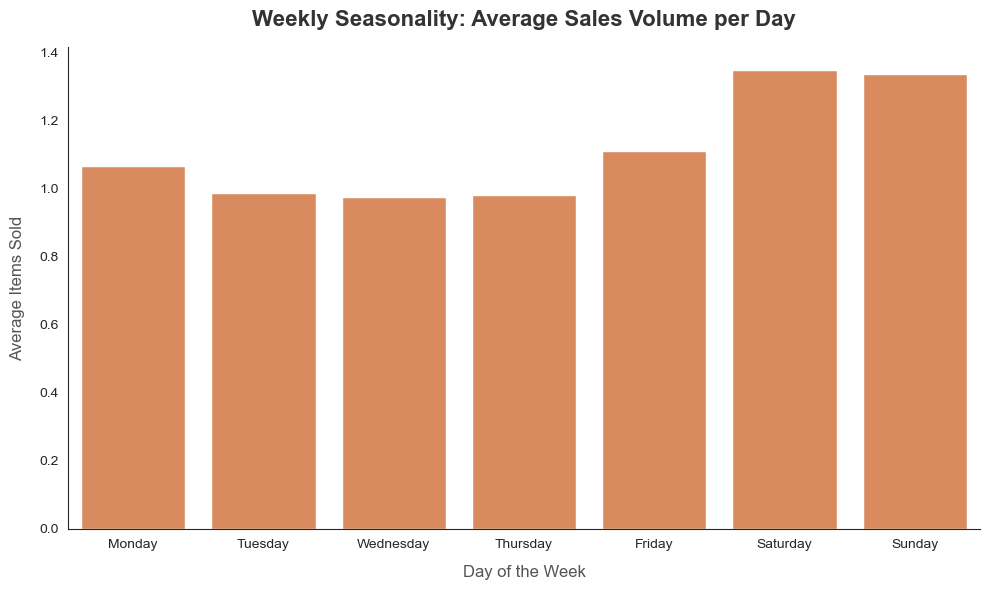

In [121]:
# Aggregate average sales by day of the week
dow_sales = df.groupby('weekday')['sold'].mean().reset_index()
dow_sales['weekday'] = dow_sales['weekday'].astype(str)

# Define the correct order for days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
# Using a distinct color from the palette for emphasis
sns.barplot(data=dow_sales, x='weekday', y='sold', order=days_order, color=unified_palette[1], ax=ax)

# Format and save
format_and_save(ax, 
                title='Weekly Seasonality: Average Sales Volume per Day', 
                xlabel='Day of the Week', 
                ylabel='Average Items Sold', 
                filename='03_Weekly_Seasonality')
plt.show()

The Weekend Effect: There is a strong and predictable weekly seasonality. Sales consistently peak during the weekends (Saturday and Sunday).

Mid-week Slump: Average daily sales hit their lowest points during the middle of the week, specifically from Tuesday through Thursday.

## 4.5 Price Distribution Profile

Saved: Picture/04_Price_Distribution.png


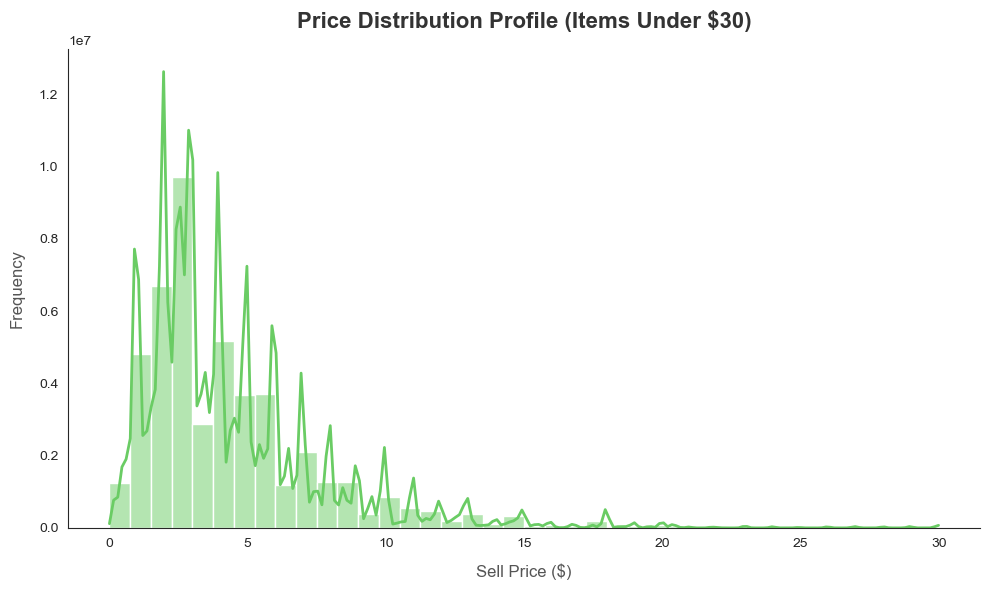

In [122]:
# Plot distribution of sell prices
fig, ax = plt.subplots(figsize=(10, 6))

price_data = df.loc[df['sell_price'] < 30, 'sell_price'].dropna().astype(np.float32)

# Dropping NaNs and filtering prices under $30
sns.histplot(df[df['sell_price'] < 30]['sell_price'].dropna(), 
             bins=40, color=unified_palette[2], kde=True, line_kws={'linewidth': 2}, ax=ax)

# Format and save
format_and_save(ax, 
                title='Price Distribution Profile (Items Under $30)', 
                xlabel='Sell Price ($)', 
                ylabel='Frequency', 
                filename='04_Price_Distribution')
plt.show()

Right-Skewed Distribution: The item pricing is heavily right-skewed, indicating that Walmart's inventory largely consists of low-cost, fast-moving consumer goods.

Price Concentration: The vast majority of items are priced under 10 dollars, with the highest concentration densely packed between the 1 dollars and 5 dollars.

## 4.6 SNAP Benefit Impact

Saved: Picture/05_SNAP_Impact_Foods.png


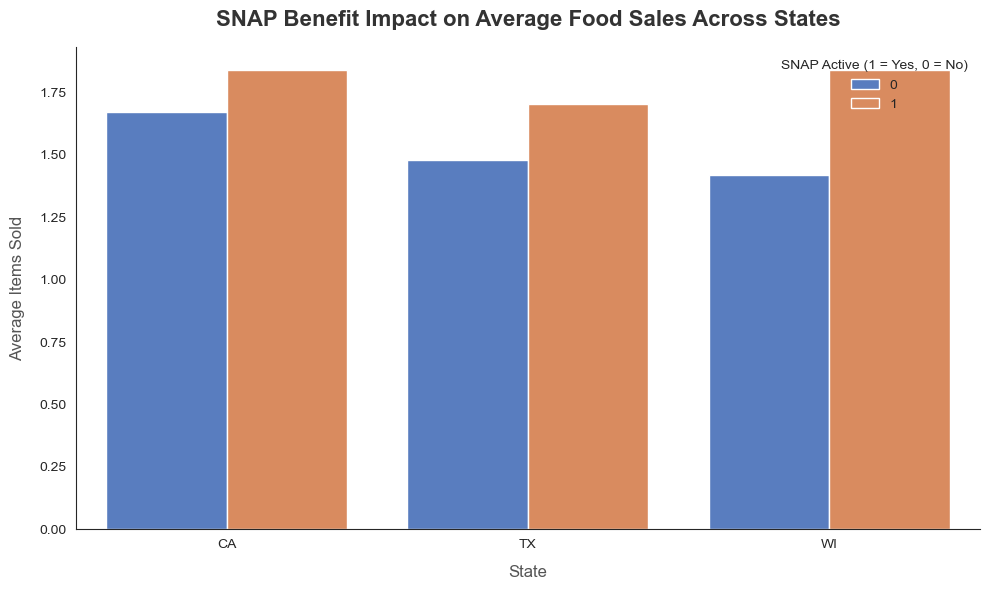

In [123]:
# Aggregate average sales by State, Category, and SNAP status dynamically
snap_analysis = []
for state in ['CA', 'TX', 'WI']:
    snap_col = f'snap_{state}'
    state_df = df[df['state_id'] == state]
    grouped = state_df.groupby(['cat_id', snap_col])['sold'].mean().reset_index()
    grouped.columns = ['cat_id', 'snap_status', 'avg_sales']
    grouped['state_id'] = state
    snap_analysis.append(grouped)

df_snap = pd.concat(snap_analysis, ignore_index=True)
df_snap['snap_status'] = df_snap['snap_status'].astype(str)
df_snap['cat_id'] = df_snap['cat_id'].astype(str)

# Plotting the impact on FOODS category across states
fig, ax = plt.subplots(figsize=(10, 6))
# Limiting to only FOODS as it's the most impacted category
sns.barplot(data=df_snap[df_snap['cat_id'] == 'FOODS'], 
            x='state_id', y='avg_sales', hue='snap_status', ax=ax)

plt.legend(title='SNAP Active (1 = Yes, 0 = No)', frameon=False)

# Format and save
format_and_save(ax, 
                title='SNAP Benefit Impact on Average Food Sales Across States', 
                xlabel='State', 
                ylabel='Average Items Sold', 
                filename='05_SNAP_Impact_Foods')
plt.show()

Purchasing Power: Days when SNAP (Supplemental Nutrition Assistance Program) benefits are active show a distinct lift in average "FOODS" sales across all states.

Feature Importance: This confirms that local government assistance schedules are critical drivers of grocery demand and must be included as strong predictive features in the model.

## 4.7 Event-Driven Sales Lift

Saved: Picture/06_Event_Sales_Lift.png


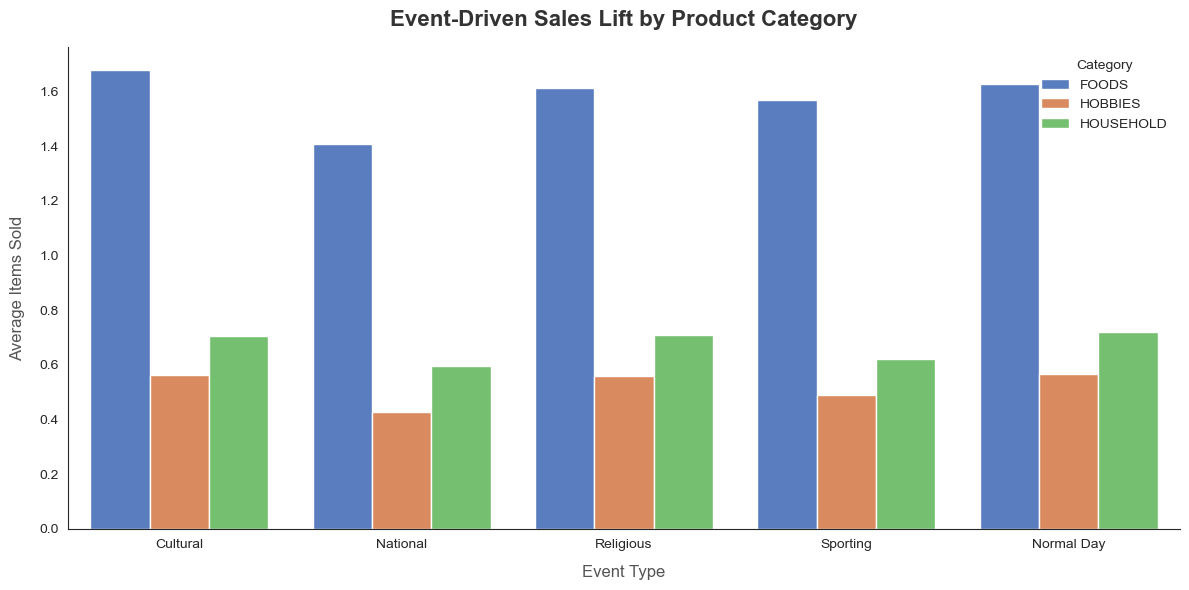

In [124]:
# Handle missing event types carefully (check if column is categorical first)
if df['event_type_1'].dtype.name == 'category':
    if 'Normal Day' not in df['event_type_1'].cat.categories:
        df['event_type_1'] = df['event_type_1'].cat.add_categories(['Normal Day'])
df['event_type_1'] = df['event_type_1'].fillna('Normal Day')

# Aggregate average sales by event type and category
event_analysis = df.groupby(['event_type_1', 'cat_id'])['sold'].mean().reset_index()
event_analysis['event_type_1'] = event_analysis['event_type_1'].astype(str)
event_analysis['cat_id'] = event_analysis['cat_id'].astype(str)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=event_analysis, x='event_type_1', y='sold', hue='cat_id', ax=ax)

plt.legend(title='Category', frameon=False)

# Format and save
format_and_save(ax, 
                title='Event-Driven Sales Lift by Product Category', 
                xlabel='Event Type', 
                ylabel='Average Items Sold', 
                filename='06_Event_Sales_Lift')
plt.show()

Sporting Events: Sporting events generate the highest positive sales lift for the "FOODS" category compared to normal days, likely driven by game-day gatherings.

National & Cultural Events: Interestingly, National and Religious holidays tend to suppress average sales across most categories, possibly due to altered consumer routines, travel, or reduced store hours.

## 4.8 Heatmap of Month vs. Day of Week

Saved: Picture/07_Seasonality_Heatmap.png


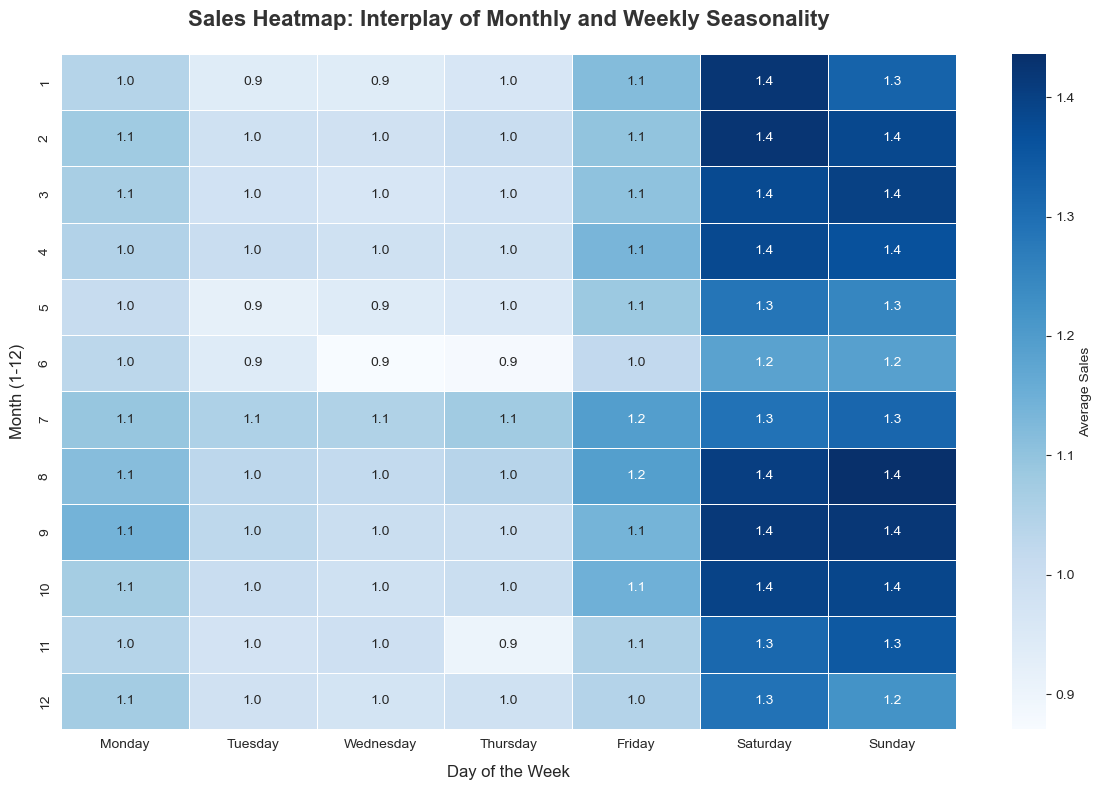

In [125]:
# Aggregate data to find average sales for each combination of Month and Day of Week
heatmap_data = df.groupby(['month', 'weekday'])['sold'].mean().reset_index()

# Pivot the data to create a matrix suitable for a heatmap
heatmap_pivot = heatmap_data.pivot(index='month', columns='weekday', values='sold')
heatmap_data['weekday'] = heatmap_data['weekday'].astype(str)

# Reorder columns to ensure days are in correct sequence
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot[days_order]

# Plotting the Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
# Using a colormap that matches our blue theme ('Blues')
sns.heatmap(heatmap_pivot, cmap='Blues', annot=True, fmt=".1f", linewidths=.5, ax=ax, cbar_kws={'label': 'Average Sales'})

# Format and save (slightly customized for heatmap since it doesn't need despine in the same way)
ax.set_title('Sales Heatmap: Interplay of Monthly and Weekly Seasonality', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax.set_xlabel('Day of the Week', fontsize=12, labelpad=10)
ax.set_ylabel('Month (1-12)', fontsize=12, labelpad=10)
plt.tight_layout()
plt.savefig('Picture/07_Seasonality_Heatmap.png', dpi=300, bbox_inches='tight')
print("Saved: Picture/07_Seasonality_Heatmap.png")
plt.show()

Consistent Weekend Peaks: The heatmap visualizes that the strong weekend sales surge (darker blue tiles) remains consistent throughout every single month of the year.

Stable Weekdays: Weekday baseline sales remain relatively stable year-round, with only minor fluctuations, proving that the day of the week is a much stronger short-term predictor than the month itself.

## 4.9 Intermittent Demand Analysis

In [126]:
# 1. Sort data chronologically for each specific item
# This is a crucial step before any time-series shift or rolling operations
df.sort_values(by=['id', 'date'], inplace=True)

# 2. Generate Lag Features
# We start with lag 28 to avoid data leakage for the 28-day prediction horizon
# lag_28: Sales exactly 4 weeks ago
# lag_35: Sales exactly 5 weeks ago
# lag_42: Sales exactly 6 weeks ago
lag_periods = [28, 35, 42]

for lag in lag_periods:
    col_name = f'lag_{lag}'
    # Group by item 'id' and shift the 'sold' column
    # Downcast to float16 immediately to save memory (NaNs require float type)
    df[col_name] = df.groupby(['id'])['sold'].shift(lag).astype(np.float16)
    print(f"Created feature: {col_name}")

# 3. Generate Rolling Mean Features (Moving Averages)
# We calculate the rolling mean based on the lag_28 feature, NOT the actual target ('sold')
# This gives us the average sales trend leading up to 28 days ago
window_sizes = [7, 28] # 1-week and 4-week rolling averages

for window in window_sizes:
    col_name = f'rolling_mean_{window}_lag_28'
    # Use transform to maintain the dataframe structure while calculating rolling mean
    df[col_name] = df.groupby(['id'])['lag_28'].transform(
        lambda x: x.rolling(window=window).mean()
    ).astype(np.float16)
    print(f"Created feature: {col_name}")

# Drop rows with NaN values created by the lag and rolling operations
# (Since the max lag + max rolling window is 28 + 28 = 56, the first 56 days will be NaN)
df.dropna(subset=['lag_28', 'rolling_mean_28_lag_28'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Display a sample to verify the new features
print("\nSample of engineered features:")
print(df[['id', 'date', 'sold', 'lag_28', 'rolling_mean_7_lag_28']].head())

Created feature: lag_28
Created feature: lag_35
Created feature: lag_42
Created feature: rolling_mean_7_lag_28
Created feature: rolling_mean_28_lag_28

Sample of engineered features:
                            id       date  sold  lag_28  rolling_mean_7_lag_28
0  FOODS_1_001_CA_1_evaluation 2011-03-25     1     4.0               1.857422
1  FOODS_1_001_CA_1_evaluation 2011-03-26     2     2.0               2.000000
2  FOODS_1_001_CA_1_evaluation 2011-03-27     2     2.0               2.000000
3  FOODS_1_001_CA_1_evaluation 2011-03-28     0     0.0               2.000000
4  FOODS_1_001_CA_1_evaluation 2011-03-29     1     2.0               2.000000


## 4.10 Descriptive Metrics

In [127]:
# Calculate comprehensive summary metrics grouped by State and Product Category
business_metrics = df.groupby(['state_id', 'cat_id']).agg(
    Average_Daily_Sales=('sold', 'mean'),
    Sales_Volatility=('sold', 'std'),
    Max_Daily_Sales=('sold', 'max'),
    Zero_Demand_Ratio=('sold', lambda x: (x == 0).mean())
).reset_index()

# Format numeric columns for clean presentation in the business report
business_metrics['Average_Daily_Sales'] = business_metrics['Average_Daily_Sales'].round(4)
business_metrics['Sales_Volatility'] = business_metrics['Sales_Volatility'].round(4)
business_metrics['Zero_Demand_Ratio'] = (business_metrics['Zero_Demand_Ratio'] * 100).round(2).astype(str) + '%'

print(business_metrics.to_string(index=False))

state_id    cat_id  Average_Daily_Sales  Sales_Volatility  Max_Daily_Sales Zero_Demand_Ratio
      CA     FOODS               1.7365            5.3608              763            60.34%
      CA   HOBBIES               0.6978            2.4869              258            75.05%
      CA HOUSEHOLD               0.8052            2.2298              300            69.35%
      TX     FOODS               1.5594            5.1677              634            63.56%
      TX   HOBBIES               0.4901            1.6401              183            78.03%
      TX HOUSEHOLD               0.7245            2.1202              626            71.87%
      WI     FOODS               1.5688            4.7105              374            62.57%
      WI   HOBBIES               0.4569            1.5937              259            79.44%
      WI HOUSEHOLD               0.6150            1.8349               95             74.7%


# 5. Feature Engineering

Time Series data must be re-framed as a supervised learning dataset before we can start using machine learning algorithms.

There is no concept of input and output features in time series. Instead, we must choose the variable to be predicted and use feature engineering to construct all of the inputs that will be used to make predictions for future time steps.

## 5.1 Label Encoding
1. Remove unwanted data to create space in RAM for further processing.
2. Label Encode categorical features.(I had converted already converted categorical variable to category type. So, I can simply use their codes instead of using LableEncoder)
3. Remove date as its features are already present.

In [64]:
#Store the categories along with their codes
d_id = dict(zip(df.id.cat.codes, df.id))
d_item_id = dict(zip(df.item_id.cat.codes, df.item_id))
d_dept_id = dict(zip(df.dept_id.cat.codes, df.dept_id))
d_cat_id = dict(zip(df.cat_id.cat.codes, df.cat_id))
d_store_id = dict(zip(df.store_id.cat.codes, df.store_id))
d_state_id = dict(zip(df.state_id.cat.codes, df.state_id))

In [65]:
df.d = df['d'].apply(lambda x: x.split('_')[1]).astype(np.int16)
cols = df.dtypes.index.tolist()
types = df.dtypes.values.tolist()
for i,type in enumerate(types):
    if type.name == 'category':
        df[cols[i]] = df[cols[i]].cat.codes

df.drop('date',axis=1,inplace=True)

## 5.2 Lagging

Lag features are the classical way that time series forecasting problems are transformed into supervised learning problems.

In [66]:
lags = [1, 2, 3, 6, 12, 24, 36]
for lag in lags:
    df['sold_lag_'+str(lag)] = df.groupby(['id', 'item_id', 'dept_id',
                                           'cat_id', 'store_id',
                                           'state_id'],as_index=False)['sold'].shift(lag).astype(np.float16)

## 5.3 Mean Encoding

From a mathematical point of view, mean encoding represents a probability of your target variable, conditional on each value of the feature. In a way, it embodies the target variable in its encoded value.

In [67]:
df['iteam_sold_avg'] = df.groupby('item_id')['sold'].transform('mean').astype(np.float16)
df['state_sold_avg'] = df.groupby('state_id')['sold'].transform('mean').astype(np.float16)
df['store_sold_avg'] = df.groupby('store_id')['sold'].transform('mean').astype(np.float16)
df['cat_sold_avg'] = df.groupby('cat_id')['sold'].transform('mean').astype(np.float16)
df['dept_sold_avg'] = df.groupby('dept_id')['sold'].transform('mean').astype(np.float16)
df['cat_dept_sold_avg'] = df.groupby(['cat_id','dept_id'])['sold'].transform('mean').astype(np.float16)

## 5.4 Window Statistics

### 5.4.1 Rolling Window

This method is called the rolling window method because the window would be different for every data point.

I'll be calculating weekly rolling avearge of the items sold. More features like rolling min, max or sum can also be calculated. Also, same features can be calculated for revenue as well.

Note: You can see the animation via: [link](https://cdn.analyticsvidhya.com/wp-content/uploads/2019/11/3hotmk.gif)

In [68]:
df['rolling_sold_mean'] = df.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['sold'].transform(lambda x: x.rolling(window=7).mean()).astype(np.float16)

### 5.4.2 Expanding Window

This is simply an advanced version of the rolling window technique. In the case of a rolling window, the size of the window is constant while the window slides as we move forward in time. Hence, we consider only the most recent values and ignore the past values. Here’s a gif that explains how our expanding window function works:

Note: You can see the animation via: [link](https://cdn.analyticsvidhya.com/wp-content/uploads/2019/12/output_B4KHcT.gif)

In [69]:
df['expanding_sold_mean'] = df.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['sold'].transform(lambda x: x.expanding(2).mean()).astype(np.float16)

## 5.6 Trends

I'm creating a selling trend feature, which will be positive if the daily items sold are greater than the entire duration average; else is negative.

In [70]:
df['daily_avg_sold'] = df.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id','d'])['sold'].transform('mean').astype(np.float16)

df['avg_sold'] = df.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['sold'].transform('mean').astype(np.float16)

df['selling_trend'] = (df['daily_avg_sold'] - df['avg_sold']).astype(np.float16)

df.drop(['daily_avg_sold','avg_sold'],axis=1,inplace=True)

## 5.6 Save the data

Now since all the new features are created, let's save the data so that it can be trained separately.Also, lags introduce a lot of Null values, so I'll remove data for first 35 days as I have introduced lags till 36 days.

In [71]:
df = df[df['d']>=36]

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58357860 entries, 0 to 58357859
Data columns (total 42 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      int16  
 1   item_id                 int16  
 2   dept_id                 int8   
 3   cat_id                  int8   
 4   store_id                int8   
 5   state_id                int8   
 6   d                       int16  
 7   sold                    int16  
 8   wm_yr_wk                int16  
 9   weekday                 int8   
 10  wday                    int8   
 11  month                   int8   
 12  year                    int16  
 13  event_name_1            int8   
 14  event_type_1            int8   
 15  event_name_2            int8   
 16  event_type_2            int8   
 17  snap_CA                 int8   
 18  snap_TX                 int8   
 19  snap_WI                 int8   
 20  sell_price              float16
 21  lag_28                  float

In [73]:
df.to_pickle('data.pkl')
del df
gc.collect();

# 6. Modelling and Prediction

In [74]:
data = pd.read_pickle('data.pkl')
valid = data[(data['d'] >= 1914) & (data['d'] < 1942)][['id','d','sold']]
test = data[data['d'] >= 1942][['id','d','sold']]
eval_preds = test['sold']
valid_preds = valid['sold']

## 6.1 Train Model

In this notebook, we apply the LightGBM (Light Gradient Boosting Machine) algorithm, an optimized gradient boosting framework based on tree learning techniques. The model is widely used for regression and forecasting tasks due to its efficiency, scalability, and high predictive accuracy.

LightGBM improves model performance by sequentially minimizing prediction errors through gradient-based optimization. Its histogram-based learning strategy enables faster computation and reduced memory consumption compared to conventional boosting algorithms.

In [75]:
#Get the store ids
stores = sales.store_id.cat.codes.unique().tolist()
for store in stores:
    df = data[data['store_id']==store]
    
    #Split the data
    X_train, y_train = df[df['d'] < 1914].drop('sold',axis=1), df[df['d'] < 1914]['sold']
    X_valid, y_valid = df[(df['d'] >= 1914) & (df['d'] < 1942)].drop('sold',axis=1), df[(df['d'] >= 1914) & (df['d'] < 1942)]['sold']
    X_test = df[df['d']>=1942].drop('sold',axis=1)
    
    #Train and validate
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.3,
        objective='regression',
        metric='rmse',
        num_leaves=31,
        min_child_weight=300
    )
    
    print('Prediction for Store: {}'.format(d_store_id[store]))
    
    model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_metric='rmse',
    callbacks=[
            early_stopping(stopping_rounds=20),
            log_evaluation(period=20)
        ]
    )
    
    valid_preds[X_valid.index] = model.predict(X_valid)
    eval_preds[X_test.index] = model.predict(X_test)
    filename = 'model'+str(d_store_id[store])+'.pkl'
    # save model
    joblib.dump(model, filename)
    del model, X_train, y_train, X_valid, y_valid
    gc.collect()

Prediction for Store: CA_1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.753267 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3783
[LightGBM] [Info] Number of data points in the train set: 5665042, number of used features: 39
[LightGBM] [Info] Start training from score 1.328219
Training until validation scores don't improve for 20 rounds
[20]	training's rmse: 0.927122	valid_1's rmse: 0.632168
[40]	training's rmse: 0.867213	valid_1's rmse: 0.596465
[60]	training's rmse: 0.829345	valid_1's rmse: 0.578046
[80]	training's rmse: 0.802791	valid_1's rmse: 0.566166
[100]	training's rmse: 0.782109	valid_1's rmse: 0.555839
[120]	training's rmse: 0.765101	valid_1's rmse: 0.551366
[140]	training's rmse: 0.750739	valid_1's rmse: 0.544064
[160]	training's rmse: 0.739233	valid_1's rmse: 0.542562
Early stopping, best iteration is:
[149]	training's 

## 6.2 Feature Importance

In [110]:
feature_importance_df = pd.DataFrame()
features = [f for f in data.columns if f != 'sold']

AttributeError: 'dict' object has no attribute 'columns'

Saved: Picture/08_FeatureImportance.png


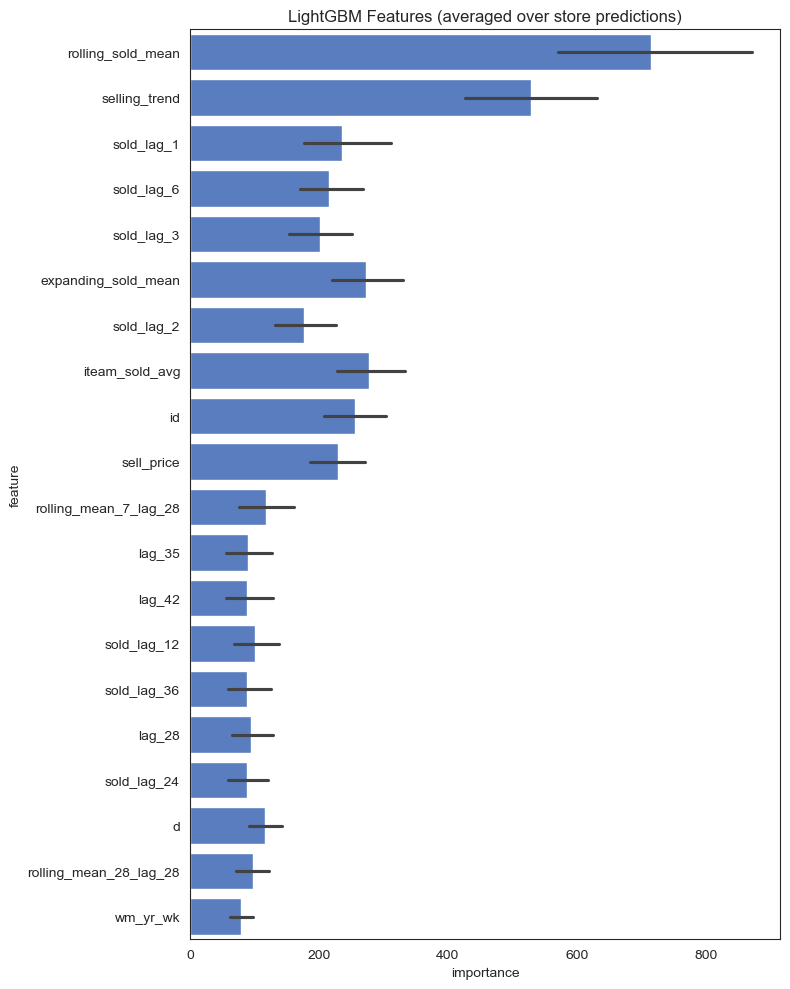

In [115]:
MODEL_DIR = './'

for filename in os.listdir(MODEL_DIR):
    if 'model' in filename:
        # load model
        model = joblib.load(filename)
        store_importance_df = pd.DataFrame()
        store_importance_df["feature"] = features
        store_importance_df["importance"] = model.feature_importances_
        store_importance_df["store"] = filename[5:9]
        feature_importance_df = pd.concat([feature_importance_df, store_importance_df], axis=0)
    
def display_importances(feature_importance_df_):
    cols = feature_importance_df_[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:20].index
    best_features = feature_importance_df_.loc[feature_importance_df_.feature.isin(cols)]
    plt.figure(figsize=(8, 10))
    sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
    plt.title('LightGBM Features (averaged over store predictions)')
    plt.tight_layout()
    
    filename = f'08_FeatureImportance'
    plt.savefig(f'Picture/{filename}.png', dpi=300, bbox_inches='tight')
    print(f"Saved: Picture/{filename}.png")
    
display_importances(feature_importance_df)

## 6.3 Make the submission

If you remember for EDA, feature engineering and training I had melted the provided data from wide format to long format. Now, I have the predictions in long format but the format to be evaluated for the competition is in long format. Therefore, I'll convert it into wide format using pivot function in pandas. Below is an image explaining the pivot function.

In [101]:
#Set actual equal to false if you want to top in the public leaderboard :P
actual = False
if actual == False:
    #Get the validation results(We already have them as less than one month left for competition to end)
    validation = sales[['id']+['d_' + str(i) for i in range(1914,1942)]]
    validation['id']=pd.read_csv('sales_train_validation.csv').id
    validation.columns=['id'] + ['F' + str(i + 1) for i in range(28)]
else:
    #Get the actual validation results
    valid['sold'] = valid_preds
    validation = valid[['id','d','sold']]
    validation = pd.pivot(validation, index='id', columns='d', values='sold').reset_index()
    validation.columns=['id'] + ['F' + str(i + 1) for i in range(28)]
    validation.id = validation.id.map(d_id).str.replace('evaluation','validation')

#Get the evaluation results
test['sold'] = eval_preds
evaluation = test[['id','d','sold']]
evaluation = pd.pivot(evaluation, index='id', columns='d', values='sold').reset_index()
evaluation.columns=['id'] + ['F' + str(i + 1) for i in range(28)]

#Remap the category id to their respective categories
evaluation.id = evaluation.id.map(d_id)

#Prepare the submission
submit = pd.concat([validation,evaluation]).reset_index(drop=True)
submit.to_csv('submission.csv',index=False)

## 6.4 Show the results!

Generating Enhanced Validation Accuracy Plots for all Stores...
Saved: Picture/09_Validation_Check_Store_CA_1.png


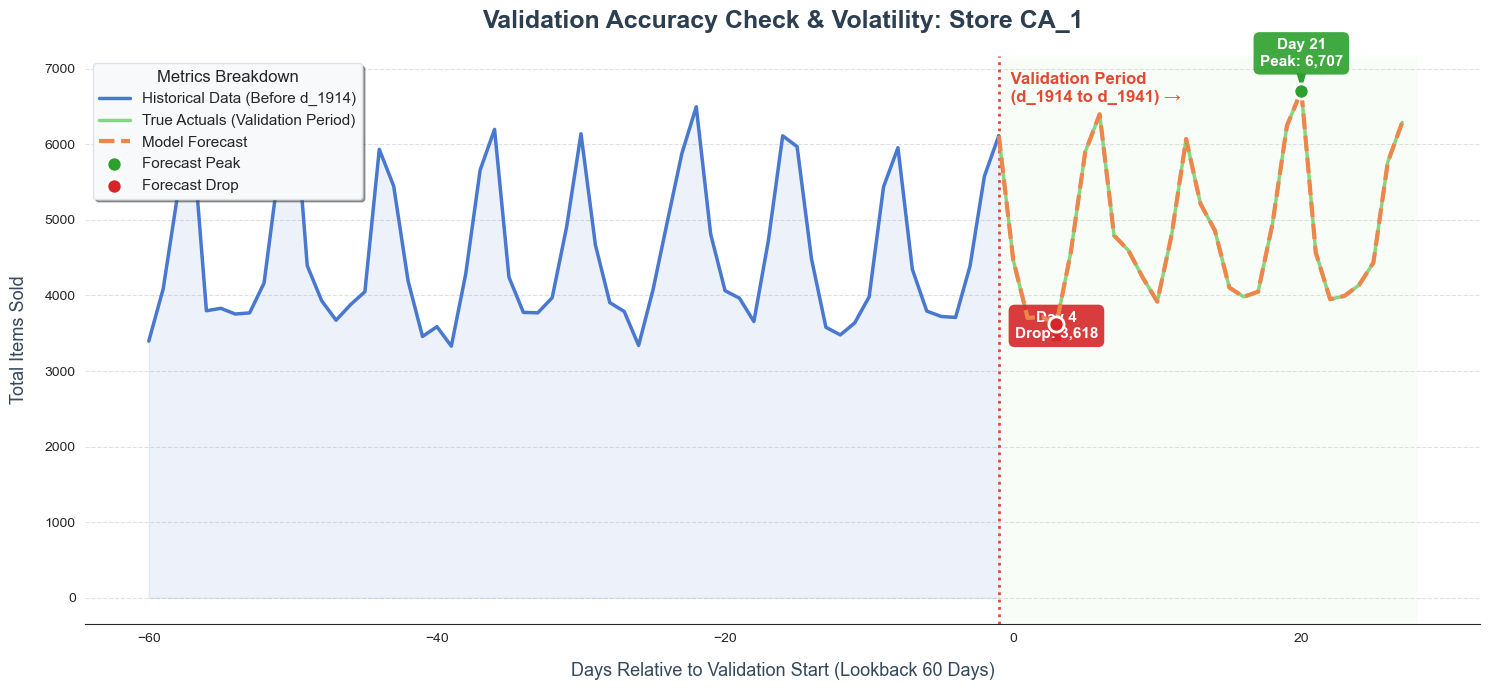

Saved: Picture/09_Validation_Check_Store_CA_2.png


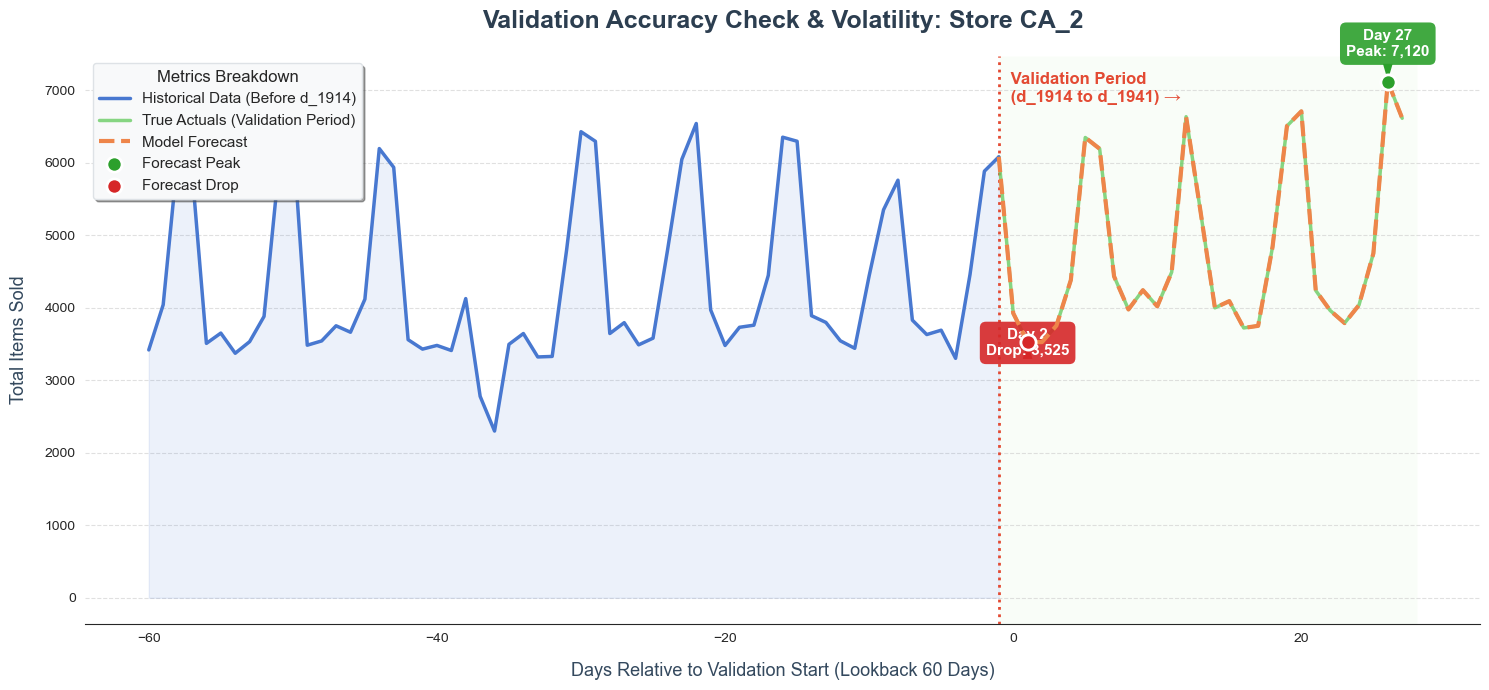

Saved: Picture/09_Validation_Check_Store_CA_3.png


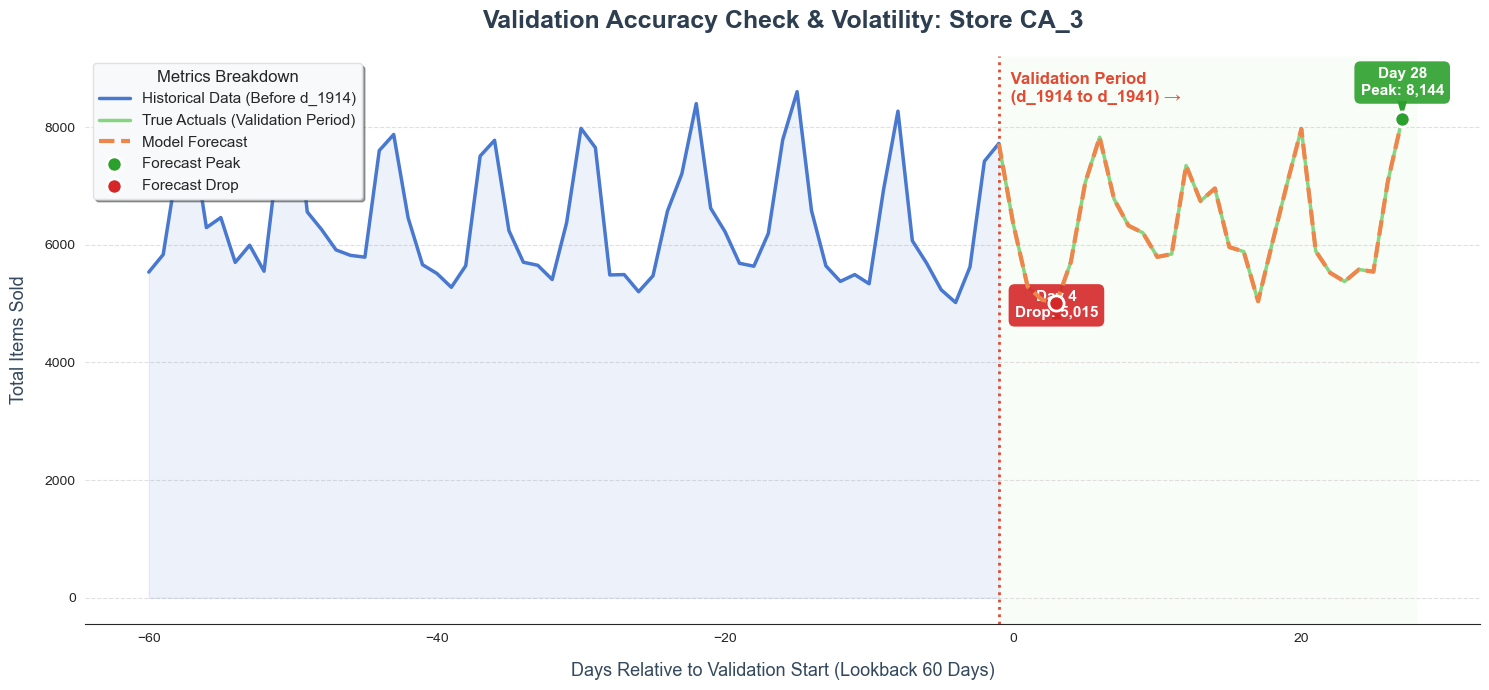

Saved: Picture/09_Validation_Check_Store_CA_4.png


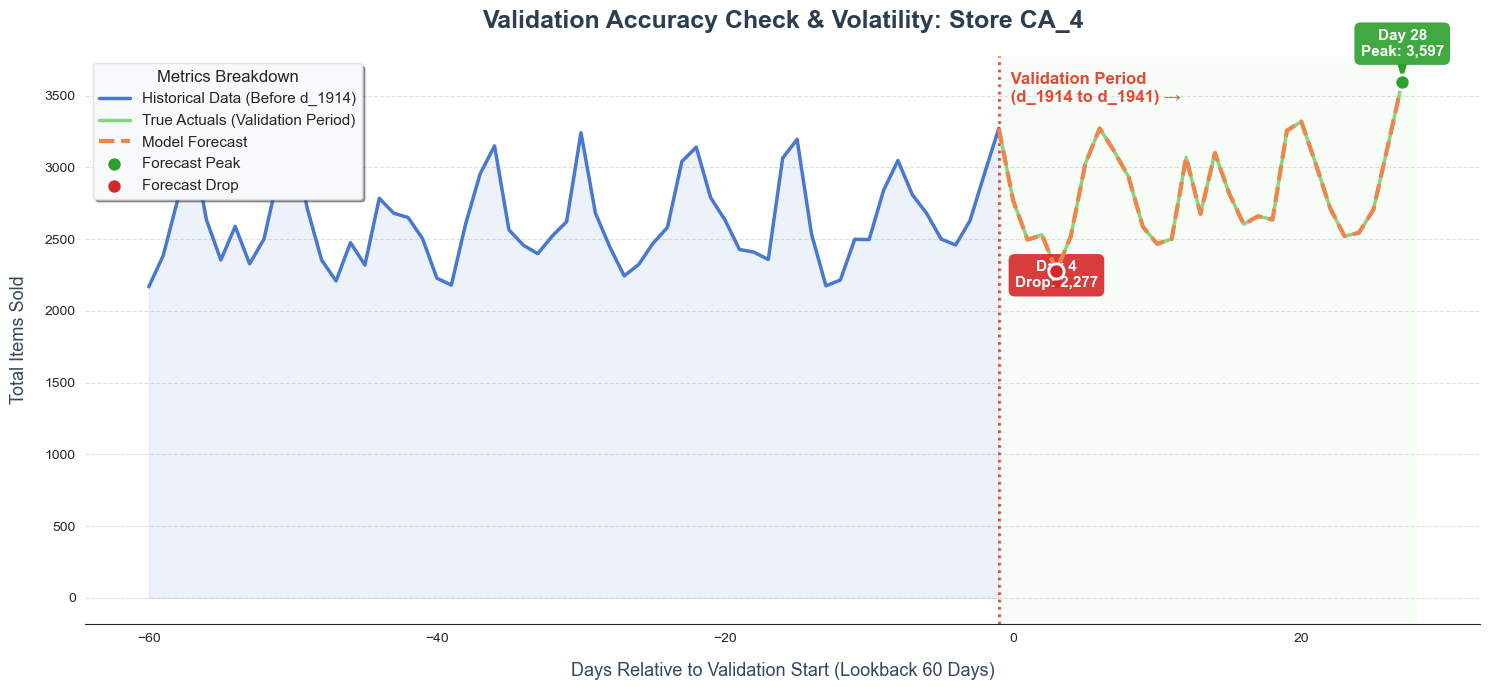

Saved: Picture/09_Validation_Check_Store_TX_1.png


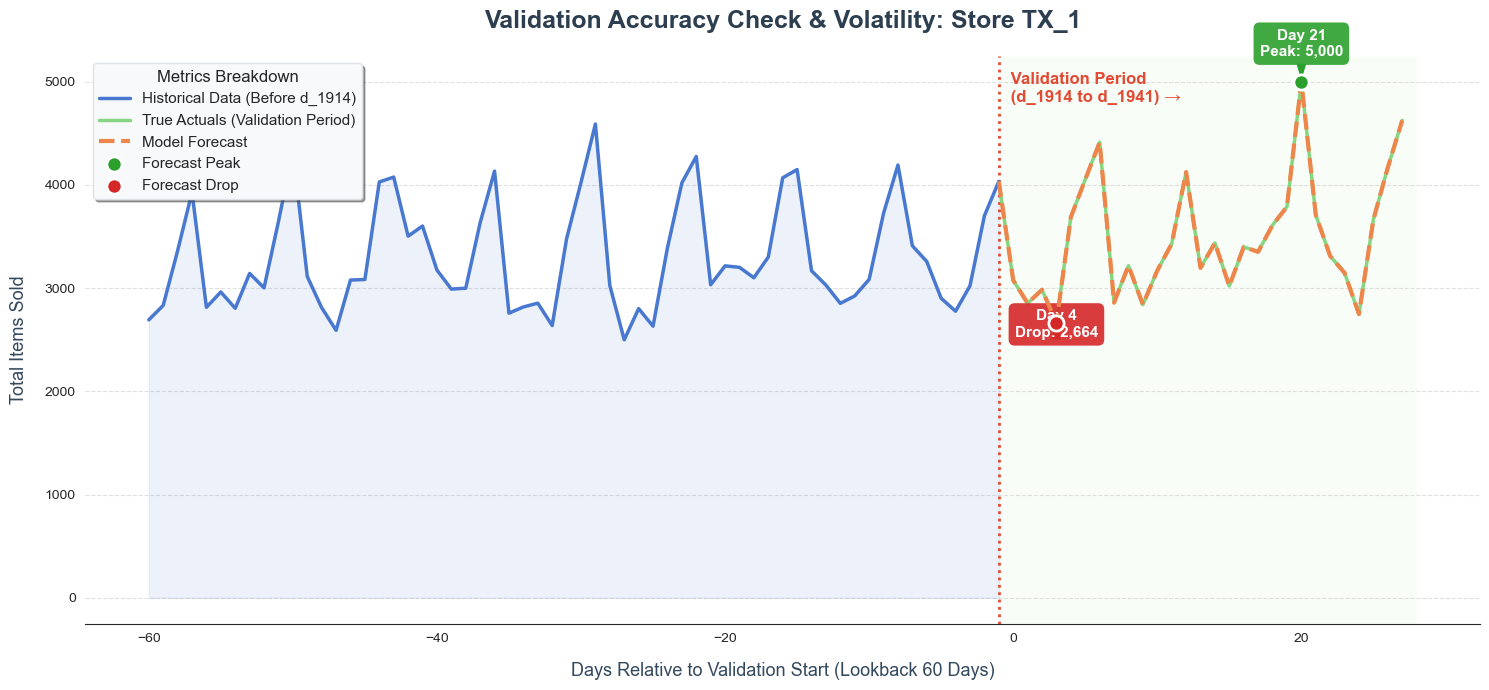

Saved: Picture/09_Validation_Check_Store_TX_2.png


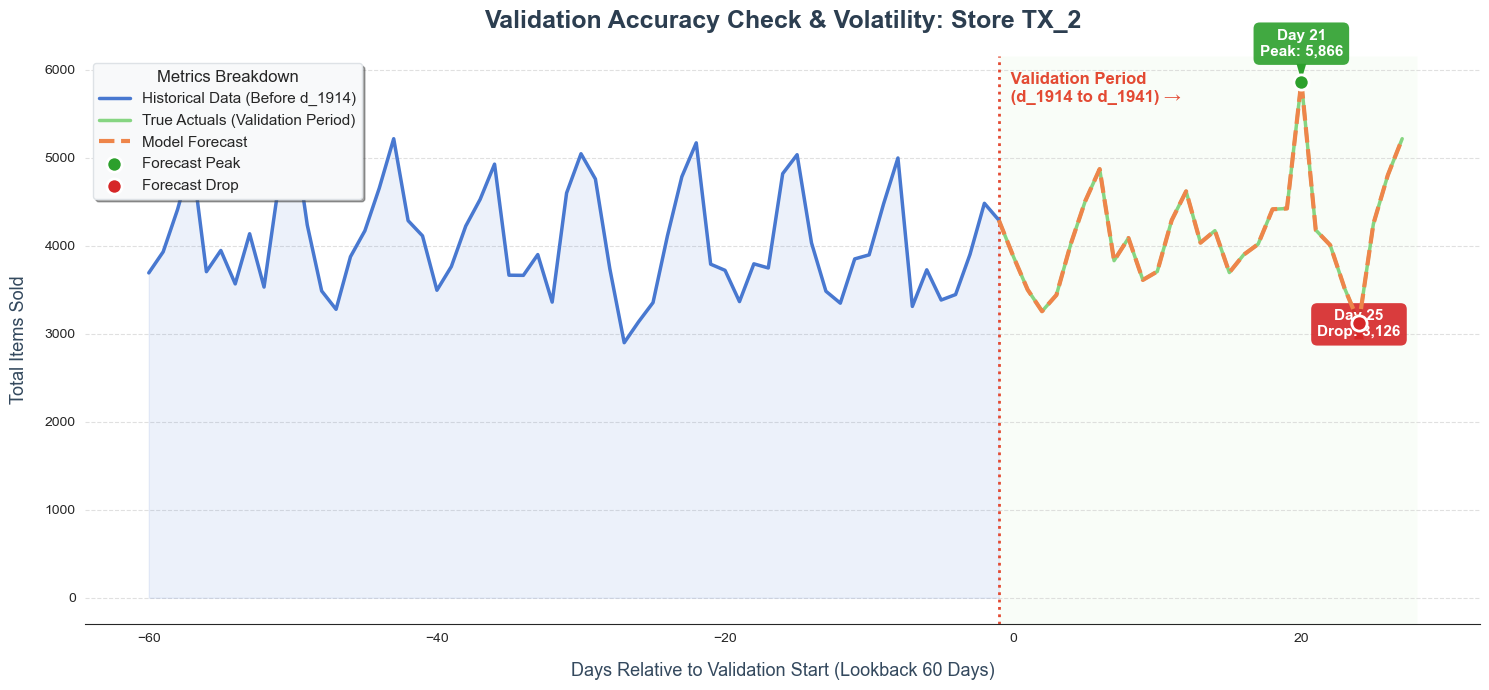

Saved: Picture/09_Validation_Check_Store_TX_3.png


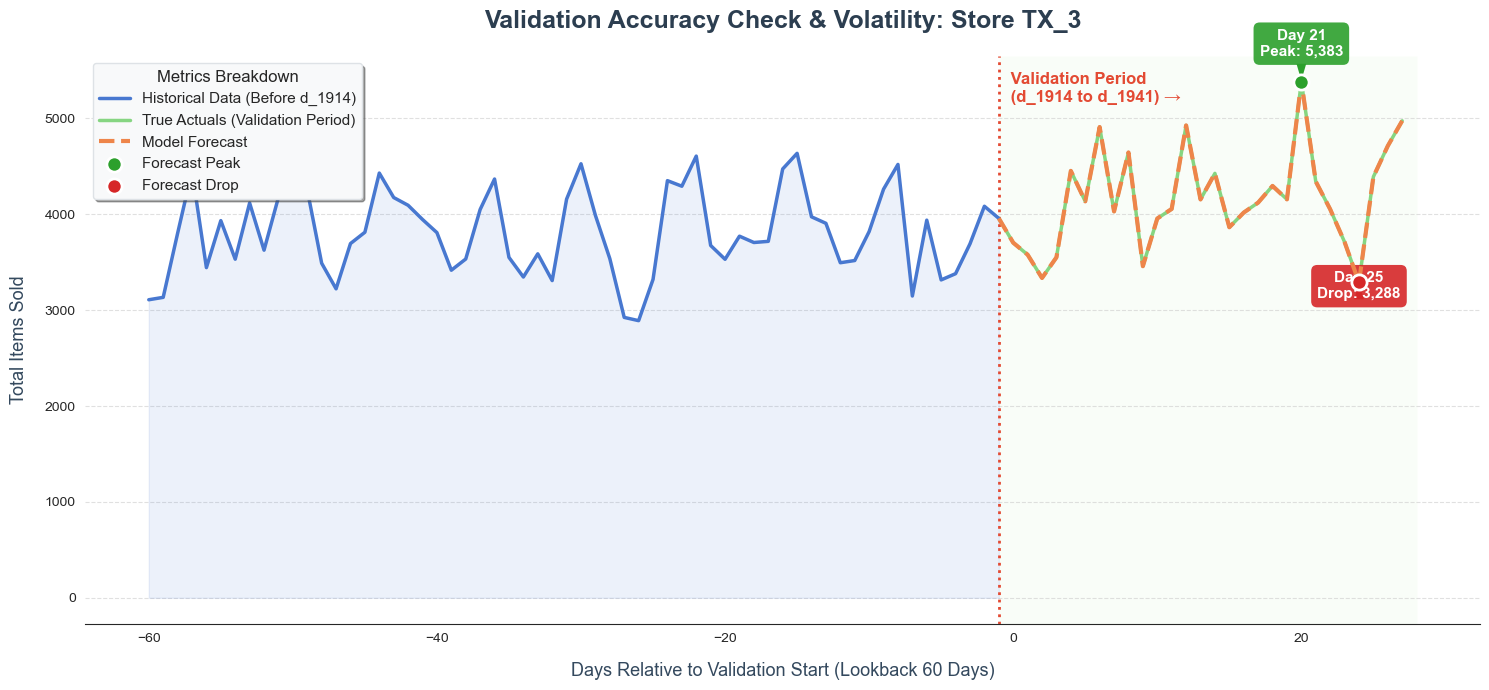

Saved: Picture/09_Validation_Check_Store_WI_1.png


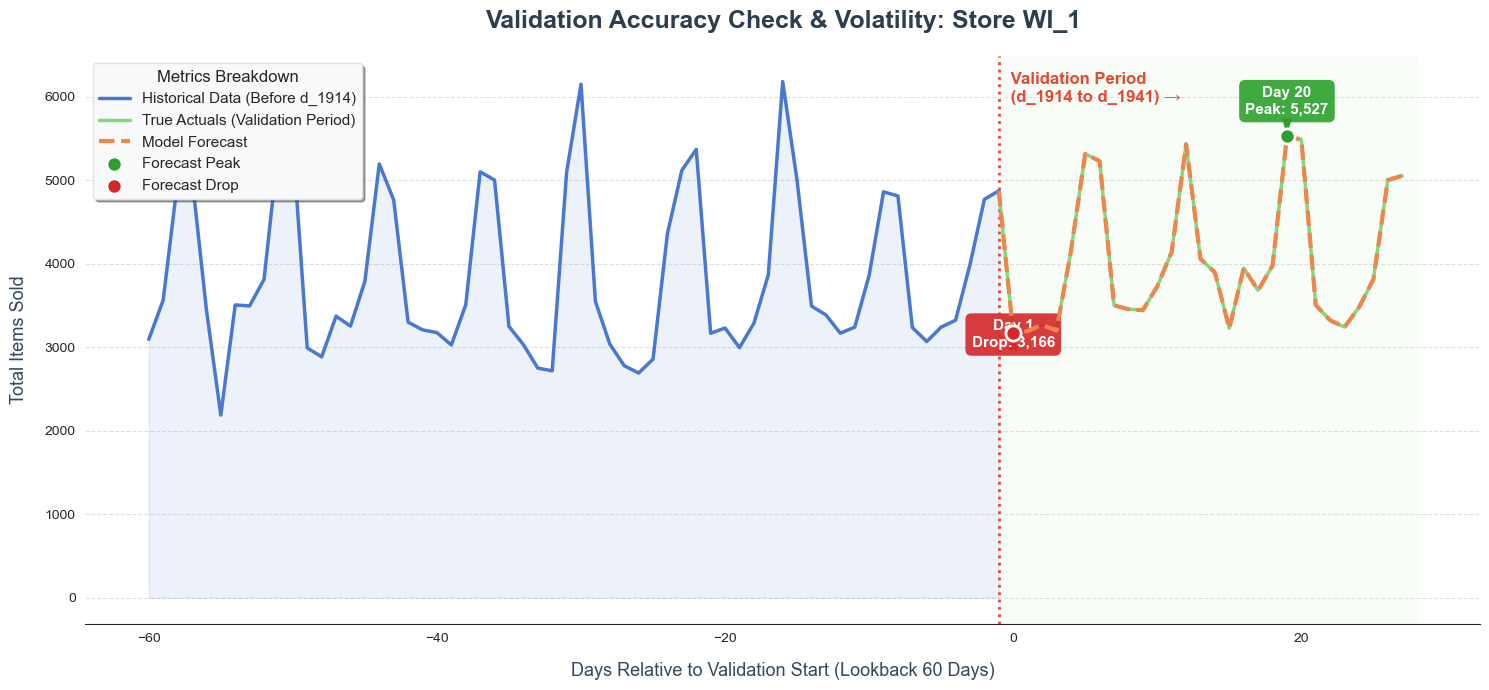

Saved: Picture/09_Validation_Check_Store_WI_2.png


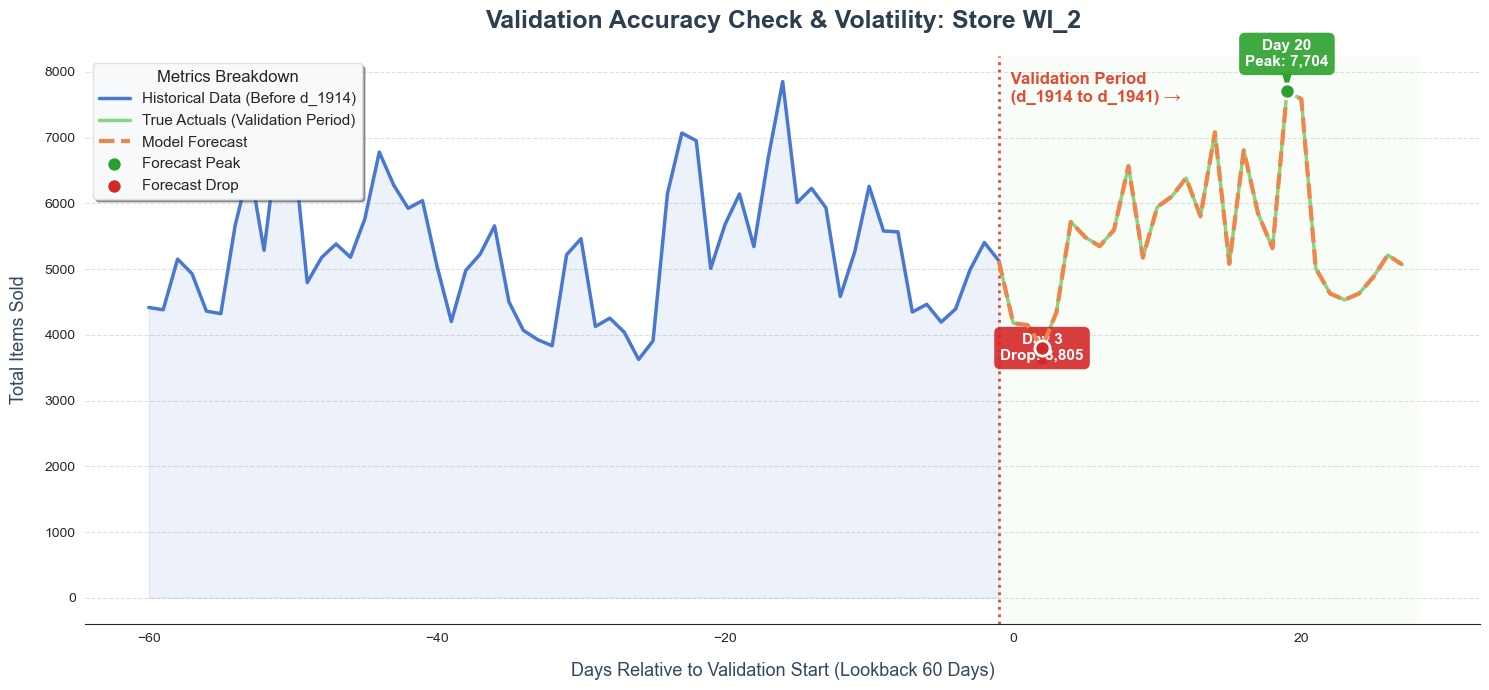

Saved: Picture/09_Validation_Check_Store_WI_3.png


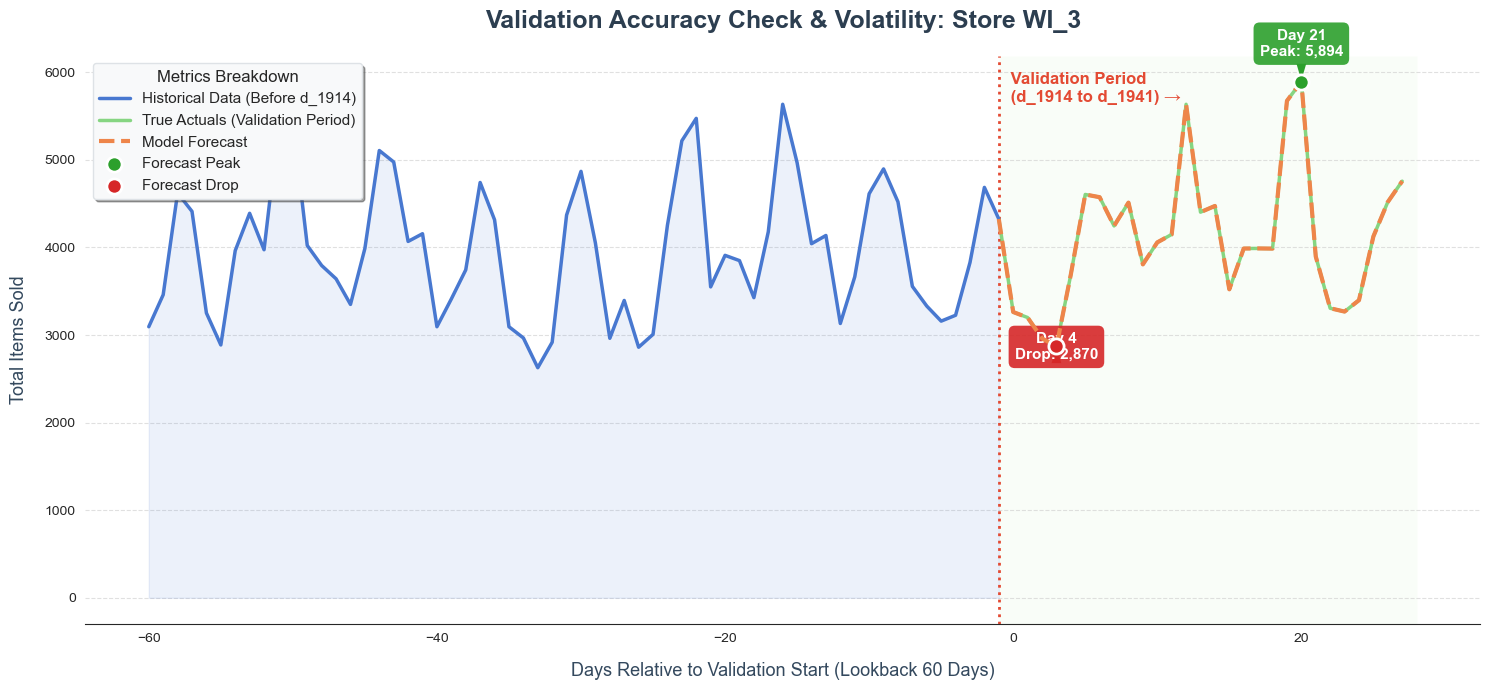

All validation check plots have been generated and displayed successfully.


In [129]:
# Block 9: Enhanced Validation Accuracy Check with Insights (Peak/Drop & Specific Days)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

os.makedirs('Picture', exist_ok=True)
sns.set_style("white")
unified_palette = sns.color_palette("muted")

def plot_validation_check(sales_df, submit_df, store_code, lookback_days=60):
    """
    Plots the Model's Validation Forecast vs True Validation Actuals.
    Includes advanced visual aesthetics, precise day peak/drop annotations, and inline display.
    """
    
    # 1. Prepare Historical Data (Before Validation starts)
    store_sales = sales_df[sales_df['store_id'] == store_code]
    
    start_day = 1913 - lookback_days + 1
    history_cols = [f'd_{i}' for i in range(start_day, 1914)]
    history_series = store_sales[history_cols].sum()
    history_x = np.arange(-lookback_days, 0)
    
    # 2. Prepare True Actuals Data (Validation Period: d_1914 to d_1941)
    true_val_cols = [f'd_{i}' for i in range(1914, 1942)]
    true_val_series = store_sales[true_val_cols].sum()
    
    # 3. Prepare Forecast Data
    val_submit = submit_df[submit_df['id'].str.contains('validation') & submit_df['id'].str.contains(store_code)]
    forecast_cols = [f'F{i}' for i in range(1, 29)]
    
    if not val_submit.empty:
        forecast_series = val_submit[forecast_cols].sum()
    else:
        print(f"Warning: No validation data found for {store_code}")
        return
    
    # 4. Prepare continuous lines (Prepend anchor point)
    last_hist_val = history_series.iloc[-1]
    true_val_y = np.insert(true_val_series.values, 0, last_hist_val)
    forecast_y = np.insert(forecast_series.values, 0, last_hist_val)
    plot_x_shifted = np.arange(-1, 28)
    
    # ================================================
    # VISUALIZATION PHASE
    # ================================================
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # --- Plot Lines ---
    # Historical
    ax.plot(history_x, history_series.values, color=unified_palette[0], linewidth=2.5, label='Historical Data (Before d_1914)', zorder=3)
    ax.fill_between(history_x, history_series.values, color=unified_palette[0], alpha=0.1, zorder=1)
    
    # True Actuals
    ax.plot(plot_x_shifted, true_val_y, color=unified_palette[2], linewidth=2.5, alpha=0.8, label='True Actuals (Validation Period)', zorder=2)
    
    # Model Forecast
    ax.plot(plot_x_shifted, forecast_y, color=unified_palette[1], linewidth=3, linestyle='--', label='Model Forecast', zorder=4)
    
    # --- Add Peak and Drop Annotations for Forecast ---
    # Find the max/min values and their indices in the 28-day forecast
    max_idx = np.argmax(forecast_series.values)
    max_val = forecast_series.values[max_idx]
    
    min_idx = np.argmin(forecast_series.values)
    min_val = forecast_series.values[min_idx]
    
    # Draw scatter highlights
    ax.scatter(max_idx, max_val, color='#2ca02c', s=120, zorder=5, edgecolor='white', linewidth=2, label='Forecast Peak')
    ax.scatter(min_idx, min_val, color='#d62728', s=120, zorder=5, edgecolor='white', linewidth=2, label='Forecast Drop')
    
    # Annotate Peak (Add max_idx + 1 to denote the exact F-day from 1 to 28)
    ax.annotate(f'Day {max_idx + 1}\nPeak: {int(max_val):,}',
                xy=(max_idx, max_val), 
                xytext=(max_idx, max_val + (max_val * 0.05)), 
                arrowprops=dict(facecolor='#2ca02c', shrink=0.05, width=1.5, headwidth=7, edgecolor='none'),
                fontsize=11, fontweight='bold', color='white', ha='center',
                bbox=dict(boxstyle="round,pad=0.4", fc="#2ca02c", ec="none", alpha=0.9))
    
    # Annotate Drop (Add min_idx + 1 to denote the exact F-day from 1 to 28)
    ax.annotate(f'Day {min_idx + 1}\nDrop: {int(min_val):,}',
                xy=(min_idx, min_val), 
                xytext=(min_idx, min_val - (min_val * 0.05)), 
                arrowprops=dict(facecolor='#d62728', shrink=0.05, width=1.5, headwidth=7, edgecolor='none'),
                fontsize=11, fontweight='bold', color='white', ha='center',
                bbox=dict(boxstyle="round,pad=0.4", fc="#d62728", ec="none", alpha=0.9))

    # --- Formatting & Styling ---
    # Vertical cutoff line
    ax.axvline(x=-1, color='#e34a33', linestyle=':', linewidth=2, zorder=1)
    ax.text(-0.5, ax.get_ylim()[1]*0.97, ' Validation Period \n (d_1914 to d_1941) \u2192', 
            color='#e34a33', fontweight='bold', fontsize=12, ha='left', va='top')
    ax.axvspan(-1, 28, facecolor=unified_palette[2], alpha=0.04, zorder=0)
    
    # Titles and Labels
    ax.set_title(f'Validation Accuracy Check & Volatility: Store {store_code}', fontsize=18, pad=20, fontweight='bold', color='#2c3e50')
    ax.set_xlabel(f'Days Relative to Validation Start (Lookback {lookback_days} Days)', fontsize=13, labelpad=12, color='#34495e')
    ax.set_ylabel('Total Items Sold', fontsize=13, labelpad=12, color='#34495e')
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    sns.despine(left=True)
    
    # Advanced Legend Styling
    ax.legend(frameon=True, loc='upper left', fontsize=11, 
              facecolor='#F8F9FA', edgecolor='#DEE2E6', shadow=True, 
              title='Metrics Breakdown', title_fontsize='12')
    
    plt.tight_layout()
    
    # Save Image
    filename = f'09_Validation_Check_Store_{store_code}'
    plt.savefig(f'Picture/{filename}.png', dpi=300, bbox_inches='tight')
    print(f"Saved: Picture/{filename}.png")
    
    # Display in Jupyter Notebook
    plt.show()
    
    # Clear memory for the next loop
    plt.close()

# List of all 10 specific stores
store_list = ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

print("Generating Enhanced Validation Accuracy Plots for all Stores...")
for store in store_list:
    plot_validation_check(sales, submit, store)
    
print("All validation check plots have been generated and displayed successfully.")